
# 23 — Ring and lattice together: the analytical toolkit

`docs/BOOLRING.md` keeps two structures side by side, and this notebook turns
the mathematical facts into the tools we actually use:

| | ring (GF(2) span) | lattice (HLLSet algebra) |
| - | - | - |
| operation | `Δ` (XOR) | `∪`, `∩`, `\` |
| what it gives | **canonical coordinates** per commit | **measurement** (BSS, D/R/N) |
| closure | subspace | Boolean lattice |

The ring does not close under `∩`, and the lattice has no small canonical
basis — so we use each for what it is exact at, and treat the mismatch as a
measurable quantity (the residual / novelty). Concretely, we build and verify:

```text
(a) base transformation   B(t-1) -> B(t)            change-of-basis matrix, exact
(b) BSS transformation    BSS(t-1) -> BSS(t)        not linear; exact by re-projection,
                                                    linear only on a disjoint basis
(c) cover identity        union(basis) = union(originals)   exact
(d) projection            X |-> (D, R, N) onto cover(t-1)   exact lattice ops
(e) minimal cover         context -> sub-basis cover        greedy (or exact support)
```

The notebook runs on real HLLSets: the flat token -> bit morphism is
reproduced bit-exactly (`mmh3`, pinned to `hllset-contracts/src/hashing.rs`),
and the ring is a transparent mirror of `crates/ewm-boolring/src/lib.rs`.


## §0 — Environment and a shared clip

Same pinned morphism as notebook 22; a 10 x 10 scene clip so there are real
scene cuts to measure novelty against.

In [1]:

import collections
import dataclasses
import itertools
import json
import pathlib
import random
import subprocess

import mmh3
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


def find_root(start):
    for anc in [start, *list(start.parents)[:4]]:
        for cand in [anc, *[p for p in anc.iterdir() if p.is_dir()]]:
            if (cand / "crates" / "ewm-boolring").exists():
                return cand
    return None


ROOT = find_root(pathlib.Path.cwd())
assert ROOT is not None, "run this notebook from the repo or its notebooks/ directory"
EWM_SCENE = ROOT / "target" / "debug" / "ewm-scene"
P, M, BITS_PER_REG = 10, 1024, 32
assert mmh3.hash64(b"tid0", seed=0, signed=False)[0] == 2_892_634_914_804_110_692


def token_position(tok):
    h = mmh3.hash64(tok.encode(), seed=0, signed=False)[0]
    reg = h & (M - 1)
    rem = h >> P
    tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
    return reg * BITS_PER_REG + tz


def hllset(tokens):
    m = 0
    for t in tokens:
        m |= 1 << token_position(t)
    return m


popcount = int.bit_count
union = lambda a, b: a | b
intersection = lambda a, b: a & b
difference = lambda a, b: a & ~b
symmetric_difference = lambda a, b: a ^ b

SCENES, FRAMES_PER_SCENE = 10, 10
BASE_TOKENS, DRIFT_TOKENS = 200, 56
TRUE_CUTS = [1 + s * FRAMES_PER_SCENE for s in range(1, SCENES)]
clip_tokens, clip_sets = [], []
for s in range(SCENES):
    base = [f"s{s}_w{j}" for j in range(BASE_TOKENS)]
    for f in range(FRAMES_PER_SCENE):
        t = s * FRAMES_PER_SCENE + f
        toks = base + [f"d{t}_{j}" for j in range(DRIFT_TOKENS)]
        clip_tokens.append(toks)
        clip_sets.append(hllset(toks))
print("clip:", len(clip_sets), "frames | cuts at", TRUE_CUTS)
print("ewm-scene:", EWM_SCENE, "(present)" if EWM_SCENE.exists() else "(will build)")

clip: 100 frames | cuts at [11, 21, 31, 41, 51, 61, 71, 81, 91]
ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene (present)



## §1 — The mirror, with the ring + lattice tools

`BoolBasis` is the same transliteration as notebook 22 plus the tool methods
that exist in `crates/ewm-boolring/src/lib.rs`:

- `cover()` (c), `bss_vector()` (b), `project()` (d), `change_of_basis()` (a),
  `linear_cover()` / `minimal_cover()` (e), `reconstruct()`.

`BoolWindow` is monotone (visibility window separate from the generator basis).

In [2]:

@dataclasses.dataclass
class RingStats:
    residual: int
    in_span: bool
    dimension: int
    rotation_count: int
    rotation_mass: int


def lowest_bit(x):
    return (x & -x).bit_length() - 1


def has_bit(x, p):
    return (x >> p) & 1 == 1


class BoolBasis:
    """Row-echelon GF(2) basis over HLLSets (Rust `BoolBasis`) + tools."""

    def __init__(self):
        self.basis = []
        self.pivots = []

    def dimension(self):
        return len(self.basis)

    def reduce(self, x):
        used = []
        while x:
            p = lowest_bit(x)
            if p in self.pivots:
                j = self.pivots.index(p)
                x ^= self.basis[j]
                used.append(j)
            else:
                return x, used
        return 0, used

    def residual(self, x):
        return self.reduce(x)[0]

    def coordinates(self, x):
        residual, used = self.reduce(x)
        if residual:
            return None
        coords = [False] * len(self.basis)
        for j in used:
            coords[j] = not coords[j]
        return coords

    def reconstruct(self, coords):
        x = 0
        for c, b in zip(coords, self.basis):
            if c:
                x ^= b
        return x

    def insert(self, x):
        residual, used = self.reduce(x)
        if residual == 0:
            return {"kind": "in_span", "coords": used}
        pivot = lowest_bit(residual)
        rotation_count = 0
        for i in range(len(self.basis)):
            if has_bit(self.basis[i], pivot):
                self.basis[i] ^= residual
                rotation_count += 1
        self.pivots.append(pivot)
        self.basis.append(residual)
        return {"kind": "added", "residual": residual, "pivot": pivot,
                "rotation_count": rotation_count}

    # ── (a) change of basis ────────────────────────────────────────────────
    def change_of_basis(self, source):
        """Columns: each `source` basis element expressed in `self`."""
        return [self.coordinates(b) for b in source.basis]

    # ── (b) lattice measurement ────────────────────────────────────────────
    def bss_vector(self, x):
        return [popcount(x & b) / popcount(b) if popcount(b) else 1.0
                for b in self.basis]

    # ── (c) cover ──────────────────────────────────────────────────────────
    def cover(self):
        c = 0
        for b in self.basis:
            c |= b
        return c

    # ── (d) projection onto the cover ──────────────────────────────────────
    def project(self, x):
        cover = self.cover()
        return {"retained": x & cover, "novelty": x & ~cover,
                "departed": cover & ~x, "cover": cover}

    # ── (e) covers ─────────────────────────────────────────────────────────
    def linear_cover(self, x):
        coords = self.coordinates(x)
        return None if coords is None else [i for i, c in enumerate(coords) if c]

    def minimal_cover(self, x):
        covered, chosen = 0, []
        while (x & ~covered):
            best, best_gain = None, 0
            for i, b in enumerate(self.basis):
                if i in chosen:
                    continue
                gain = popcount(x & ~covered & b)
                if gain > best_gain:
                    best, best_gain = i, gain
            if best is None:
                break
            covered |= self.basis[best]
            chosen.append(best)
        return chosen


class BoolWindow:
    """Ring over originals: monotone basis + visibility window (Rust `BoolWindow`)."""

    def __init__(self, max_len, evict_basis=False):
        self.max_len = max(1, max_len)
        self.evict_basis = evict_basis
        self.originals = collections.deque()
        self.basis = BoolBasis()
        self.total = 0
        self._generation = 0

    def window_len(self):
        return len(self.originals)

    def dimension(self):
        return self.basis.dimension()

    def generation(self):
        return self._generation

    def push(self, x):
        result = self.basis.insert(x)
        if result["kind"] == "in_span":
            residual, in_span, rotation_count = 0, True, 0
        else:
            residual = popcount(result["residual"])
            in_span, rotation_count = False, result["rotation_count"]
            self._generation += 1
        self.originals.append(x)
        self.total += 1
        dimension = self.basis.dimension()
        if len(self.originals) > self.max_len:
            self.originals.popleft()
            if self.evict_basis:
                self.basis = BoolBasis()
                for s in self.originals:
                    self.basis.insert(s)
                self._generation += 1
                dimension = self.basis.dimension()
        return RingStats(residual, in_span, dimension, rotation_count,
                         rotation_count * residual)

    def residual(self, x):
        return self.basis.residual(x)

    def coordinates(self, x):
        return self.basis.coordinates(x)


def basis_over(sets):
    b = BoolBasis()
    for s in sets:
        b.insert(s)
    return b


print("mirror ready: BoolBasis (with tools) + monotone BoolWindow")

mirror ready: BoolBasis (with tools) + monotone BoolWindow



## §2 — Ring coordinates and lattice BSS measure the same commit

For a commit (an original frame HLLSet) the ring gives a unique coordinate
vector once the basis generation is fixed, and the lattice gives the BSS soft
key against every basis element. This is the coexistence: exact structure on
one side, toleranced measurement on the other.

In [3]:

basis = basis_over(clip_sets)          # monotone basis over the whole clip
x = clip_sets[41]                      # a frame near a cut

coords = basis.coordinates(x)
print("ring  : frame 42 coordinates -> support size %d, |support|/dim = %.3f"
      % (sum(coords), sum(coords) / basis.dimension()))
print("ring  : reconstruct(coords) == frame 42:", basis.reconstruct(coords) == x)

w = basis.bss_vector(x)
w = np.array(w)
print("lattice: BSS vector length %d | max %.3f | mean %.3f | nonzero %d"
      % (len(w), w.max(), w.mean(), int((w > 0).sum())))
print("lattice: top-5 BSS basis elements:", np.argsort(w)[-5:][::-1].tolist())

ring  : frame 42 coordinates -> support size 6, |support|/dim = 0.060
ring  : reconstruct(coords) == frame 42: True
lattice: BSS vector length 100 | max 0.165 | mean 0.063 | nonzero 98
lattice: top-5 BSS basis elements: [46, 91, 45, 3, 20]



## §3 — (a) Base transformation `B(t-1) -> B(t)`

With a monotone basis, `span(t-1) ⊆ span(t)`, so every old basis element has
unique coordinates in the new basis: the columns of the **change-of-basis
matrix** `M`. Any coordinate vector `a` transports by `a · M` — exactly, and
cheaply. This is what keeps coordinates canonical across commits.

In [4]:

b50 = basis_over(clip_sets[:50])
b100 = basis_over(clip_sets[:100])
COB = b100.change_of_basis(b50)        # columns: old basis in the new basis
present = sum(c is not None for c in COB)
print("dim(t-1)=%d -> dim(t)=%d | old columns representable: %d/%d"
      % (b50.dimension(), b100.dimension(), present, b50.dimension()))
density = sum(sum(c) for c in COB if c is not None) / (b100.dimension() * b50.dimension())
print("change-of-basis density: %.3f (GF(2) matrix, mostly sparse)" % density)

# transport a real coordinate vector across the commit boundary
x = clip_sets[30]
a_old = b50.coordinates(x)
a_new = b100.coordinates(x)
a_transported = [False] * b100.dimension()
for j, col in enumerate(COB):
    if a_old[j]:
        for i, bit in enumerate(col):
            a_transported[i] ^= bit
print("a_old · M == a_new:", a_transported == a_new)
print("reconstruct in new basis:", b100.reconstruct(a_transported) == x)

dim(t-1)=50 -> dim(t)=100 | old columns representable: 50/50
change-of-basis density: 0.038 (GF(2) matrix, mostly sparse)
a_old · M == a_new: True
reconstruct in new basis: True



## §4 — (b) BSS transformation `BSS(t-1) -> BSS(t)`

This one is **not** a linear map of the soft key. If
`B_j^t = Δ_{i∈S} B_i^{t-1}`, then `X ∩ B_j^t = Δ_{i∈S} (X ∩ B_i^{t-1})`,
whose popcount is not determined by the individual `|X ∩ B_i^{t-1}|` — XOR
cancellation depends on overlaps. So the exact tool is **re-projection**
(`bss_vector` against the new basis, `O(dim)` intersections). A linear
transport exists only on a **disjoint** basis, where XOR = union and the
counts add; we measure both.

In [5]:

# Minimal demonstration of the non-linearity: old basis {x,y}, {y,z};
# new element c = {x,y} Δ {y,z} = {x,z}; X = {y}.
a, b = hllset(["x", "y"]), hllset(["y", "z"])
c = symmetric_difference(a, b)
ex_old = basis_over([a, b])
w_old = np.array(ex_old.bss_vector(hllset(["y"])))
num = sum(w_old[i] * popcount(ex_old.basis[i]) for i in range(2))  # XOR as union
print("overlap example: old BSS =", np.round(w_old, 2).tolist())
print("  linear transport predicts BSS(X, c) = %.2f" % (num / popcount(c)))
print("  exact re-projection             = %.2f"
      % (popcount(hllset(["y"]) & c) / popcount(c)))
print("  -> the linear map is wrong whenever the old generators overlap")

# On the real clip the linear transport is defined only for new basis
# elements that already lie in the old span; the rest are extensions with no
# old-side information at all.
pops_old = [popcount(z) for z in b50.basis]
pops_new = [popcount(z) for z in b100.basis]
cols_new_in_old = b50.change_of_basis(b100)
definable = [j for j, col in enumerate(cols_new_in_old) if col is not None and any(col)]
print("\nreal clip: %d/%d new basis elements lie in the old span (transport defined);"
      % (len(definable), b100.dimension()))
print("  the other %d are extensions (genuinely new directions)."
      % (b100.dimension() - len(definable)))

errs = []
for xx in clip_sets[:40]:
    w0 = np.array(b50.bss_vector(xx))
    w1 = np.array(b100.bss_vector(xx))
    for j in definable:
        pred = sum(w0[i] * pops_old[i] for i, cc in enumerate(cols_new_in_old[j]) if cc) / pops_new[j]
        errs.append(abs(pred - w1[j]))
print("exact vs linear on the definable columns: mean |error| = %.3f, max = %.3f"
      % (float(np.mean(errs)), float(np.max(errs))))

# Disjoint basis: XOR == union, counts add -> the linear transport is exact.
d = BoolBasis()
for s in [hllset([f"p{j}"]) for j in range(8)]:
    d.insert(s)
d2 = BoolBasis()
for s in [hllset([f"p{j}"]) for j in range(8)] + [hllset([f"q{j}"]) for j in range(4)]:
    d2.insert(s)
cols_d2_in_d = d.change_of_basis(d2)
pd_old = [popcount(z) for z in d.basis]
pd_new = [popcount(z) for z in d2.basis]
y = hllset(["p1", "p2", "q1"])
w_d_old = np.array(d.bss_vector(y))
pred_d, exact_d = [], []
for j, col in enumerate(cols_d2_in_d):
    exact_d.append(popcount(y & d2.basis[j]) / pd_new[j])
    if col is None or not any(col):
        pred_d.append(float("nan"))
        continue
    pred_d.append(sum(w_d_old[i] * pd_old[i] for i, cc in enumerate(col) if cc) / pd_new[j])
pred_d, exact_d = np.array(pred_d), np.array(exact_d)
ok = ~np.isnan(pred_d)
print("disjoint basis: max |error| = %.2e (exact)"
      % float(np.max(np.abs(pred_d[ok] - exact_d[ok]))))

overlap example: old BSS = [0.5, 0.5]
  linear transport predicts BSS(X, c) = 1.00
  exact re-projection             = 0.00
  -> the linear map is wrong whenever the old generators overlap

real clip: 9/100 new basis elements lie in the old span (transport defined);
  the other 91 are extensions (genuinely new directions).
exact vs linear on the definable columns: mean |error| = 0.000, max = 0.000
disjoint basis: max |error| = 0.00e+00 (exact)



### §4b — Rotating BSS exactly: the meet-order ladder

The rotation is a change of basis, but the transform is **quadratic and
higher**, not linear. From `B_j^t = Δ_{i∈S} B_i^{t-1}`,

```text
X ∩ B_j^t = Δ_{i∈S} (X ∩ B_i^{t-1}),
```

and the XOR cardinality expands over the **meet table** of the old basis:

```text
|Δ_{i∈S} A_i| = Σ_{∅≠T⊆S} (-1)^{|T|+1} 2^{|T|-1} |∩_{i∈T} A_i|,
    A_i = X ∩ B_i^{t-1},   |∩_{i∈T} A_i| = |X ∩ ∩_{i∈T} B_i^{t-1}|.
```

So the first-order BSS vector is **not a sufficient state** for rotation: to
rotate without the bit planes you must carry the sub-basis meet counts down to
the support size of each new element. Truncating the sum at order `d` is exact
for every new element whose old-basis support has size `≤ d`; the `d = 1`
truncation is the linear/disjoint approximation, and the omitted terms are the
meet mass.

Two regimes matter in practice:

- **pure re-basis** (same span, different basis — e.g. comparing windows or
  insertion orders): every new element is in the old span, and the ladder is
  the exact rotation. This is where the meet table is what you need;
- **extension** (the span grows): a genuinely new direction `R` has no
  old-side coordinates at all, so no BSS state predicts it — you must measure
  `X ∩ R` (the new original) and then use the ladder for the re-pivoted
  elements. That is exactly why the window keeps the new commit as a generator.

In [6]:

def meet_count(x, idxs, basis):
    """|X ∩ ∩_{i∈idxs} B_i| — one entry of the meet table."""
    s = x
    for i in idxs:
        s &= basis.basis[i]
    return popcount(s)


def rotate_popcount(x, support, basis, order=None):
    """|X ∩ Δ_{i∈support} B_i| by inclusion-exclusion over the meet table.

    Exact when `order >= len(support)`; `order=1` is the linear approximation.
    """
    total = 0
    top = len(support) if order is None else min(len(support), order)
    for d in range(1, top + 1):
        for T in itertools.combinations(support, d):
            total += (-1) ** (d + 1) * (2 ** (d - 1)) * meet_count(x, T, basis)
    return total


# Pure re-basis: the same span built two ways (forward vs reverse insertion).
# Every new element is in the old span, so the ladder is the exact rotation.
sets12 = clip_sets[:12]
b12 = basis_over(sets12)
b12r = basis_over(list(reversed(sets12)))
cols = b12.change_of_basis(b12r)          # reverse-basis elements in the forward basis
pairs = [(j, [i for i, cc in enumerate(col) if cc])
         for j, col in enumerate(cols) if col is not None]
sizes = [len(sup) for _, sup in pairs]
print("pure re-basis: %d new elements in the old span | support sizes max %d, mean %.2f"
      % (len(pairs), max(sizes), float(np.mean(sizes))))

X = clip_sets[5]
exact_num = [popcount(X & b12r.basis[j]) for j, _ in pairs]
for d in (1, 2, 3):
    err = [abs(rotate_popcount(X, sup, b12, order=d) - ex)
           for (_, sup), ex in zip(pairs, exact_num)]
    print("  order-%d truncation: mean |error| = %7.2f  max = %7.2f"
          % (d, float(np.mean(err)), float(np.max(err))))

dmax = max(sizes)
ok_all = all(rotate_popcount(X, sup, b12, order=dmax) == ex
             for (_, sup), ex in zip(pairs, exact_num))
print("order = max support (%d) reproduces the bit-plane re-projection exactly: %s"
      % (dmax, ok_all))

# Extension check: forward one step, the new direction is not in the old span,
# so its BSS cannot come from the old BSS state at all.
b59 = basis_over(clip_sets[:59])
b60 = basis_over(clip_sets[:60])
ext = b59.change_of_basis(b60)
new_dirs = sum(1 for col in ext if col is None)
print("extension step 59->60: %d/%d new elements outside the old span (must be measured, not rotated)"
      % (new_dirs, b60.dimension()))

pure re-basis: 12 new elements in the old span | support sizes max 3, mean 1.17
  order-1 truncation: mean |error| =    1.00  max =   12.00
  order-2 truncation: mean |error| =    0.00  max =    0.00
  order-3 truncation: mean |error| =    0.00  max =    0.00
order = max support (3) reproduces the bit-plane re-projection exactly: True
extension step 59->60: 1/60 new elements outside the old span (must be measured, not rotated)



## §5 — (c) The cover identity: `union(basis) = union(originals)`

Every basis element is an XOR of generators, and `XOR ⊆ OR`, so the cover of
the basis is contained in the union of the generators; every generator is an
XOR of basis elements, so the reverse inclusion holds too. The identity is
exact, in monotone and windowed mode. It gives the bit plane the ring can see:
`X \ cover` is novelty no span member can contain.

In [7]:

all_union = 0
for s in clip_sets:
    all_union |= s

for name, w in [("monotone (all 100 generators)", BoolWindow(12)),
                ("windowed (legacy, 12 visible)", BoolWindow(12, evict_basis=True))]:
    for s in clip_sets:
        w.push(s)
    cover = w.basis.cover()
    if name.startswith("monotone"):
        expected = all_union
    else:
        expected = 0
        for s in w.originals:
            expected |= s
    print("%-32s cover == union(generators): %s" % (name, cover == expected))
print("monotone cover popcount: %d of %d plane bits" % (popcount(basis.cover()), 1 << 15))

monotone (all 100 generators)    cover == union(generators): True
windowed (legacy, 12 visible)    cover == union(generators): True
monotone cover popcount: 3294 of 32768 plane bits



## §6 — (d) Projection `X -> (D, R, N)` onto `cover(t-1)`

Bit-level, exact lattice operations: retained `R = X ∩ cover`, novelty
`N = X \ cover`, departed `D = cover \ X`, with `X = R ⊔ N`. This is the
practical novelty signal the sidecar should use: `N` counts bits that cannot
be in the span at all, and it is contained in the ring residual (which also
contains re-indexable bits). Scene cuts separate cleanly.

bit novelty N at cuts   : mean 99.0
bit novelty N in-scene  : mean 26.4  (separation 3.75x)
N is inside the ring residual for every frame: True
frame 11: R=50 N=189 D=616 | (R|N)==frame: True | R&N empty: True


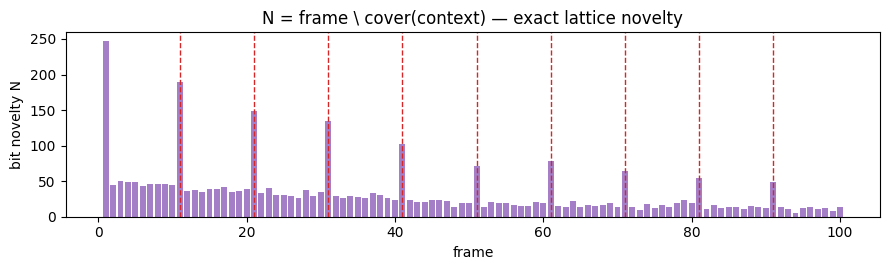

In [8]:

# Rolling context: project each frame onto the cover of the EARLIER frames.
cut_idx = [c - 1 for c in TRUE_CUTS]
in_idx = [i for i in range(len(clip_sets)) if i not in set(cut_idx)]

prev = BoolBasis()
n_nov, n_res, p_cut = [], [], None
for i in range(len(clip_sets)):
    p = prev.project(clip_sets[i])
    n_nov.append(popcount(p["novelty"]))
    n_res.append(popcount(prev.residual(clip_sets[i])))
    if i == 10:
        p_cut = p
    prev.insert(clip_sets[i])
n_nov, n_res = np.array(n_nov), np.array(n_res)

print("bit novelty N at cuts   : mean %.1f" % n_nov[cut_idx].mean())
print("bit novelty N in-scene  : mean %.1f  (separation %.2fx)"
      % (n_nov[in_idx].mean(), n_nov[cut_idx].mean() / n_nov[in_idx].mean()))
print("N is inside the ring residual for every frame:",
      bool(np.all(n_nov <= n_res)))

# X = R and N reassemble, and D describes the context dropped
R, N, D = p_cut["retained"], p_cut["novelty"], p_cut["departed"]
print("frame 11: R=%d N=%d D=%d | (R|N)==frame: %s | R&N empty: %s"
      % (popcount(R), popcount(N), popcount(D), (R | N) == clip_sets[10], (R & N) == 0))

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(np.arange(1, 101), n_nov, color="tab:purple", alpha=0.85)
for c in TRUE_CUTS:
    ax.axvline(c, color="tab:red", ls="--", lw=1)
ax.set_ylabel("bit novelty N"); ax.set_xlabel("frame")
ax.set_title("N = frame \\ cover(context) — exact lattice novelty")
plt.tight_layout()
plt.show()


## §7 — (e) Minimal cover of a context set

Given a model-context HLLSet `C`, express it with as few basis HLLSets as
possible. Two exactnesses:

- if `C` is in the span, the **linear cover** is unique — the support of its
  coordinates (that is the minimal XOR cover, and it reconstructs `C` exactly);
- in general we want a minimal **union** cover (`⊇ C`), which is NP-hard; the
  greedy pass is `H(d)`-approximate. Bits of `C` outside the cover can never be
  covered by any basis subset (`linear_cover` returns `None`).

This is the compression tool: pick a few basis directions that already cover
the context, and keep the residual for what they cannot.

In [9]:

# A context set: the union of a scene's frames (what the model would hold).
context = 0
for s in clip_sets[20:25]:
    context |= s

greedy = basis.minimal_cover(context)
covered = 0
for i in greedy:
    covered |= basis.basis[i]
print("context popcount           : %d" % popcount(context))
print("greedy cover size          : %d basis elements" % len(greedy))
print("coverage by greedy cover   : %.3f" % (popcount(context & covered) / popcount(context)))
print("uncoverable bits (outside cover): %d" % popcount(context & ~basis.cover()))

# in-span case: the unique linear cover is the coordinate support
x = clip_sets[42]
lin = basis.linear_cover(x)
print("\nin-span frame 43          : linear cover size %d, reconstruct exact: %s"
      % (len(lin), basis.reconstruct([i in lin for i in range(basis.dimension())]) == x))
greedy_x = basis.minimal_cover(x)
print("greedy union cover size   : %d (same set is a linear combination)" % len(greedy_x))

# The extreme: a context HLLSet is itself a candidate generator. Commit it and
# the cover grows to include it exactly (monotone => permanent).
before = basis.dimension()
basis.insert(context)
print("\nafter pushing the context HLLSet: dim %d -> %d | in span now: %s"
      % (before, basis.dimension(), basis.coordinates(context) is not None))

context popcount           : 442
greedy cover size          : 12 basis elements
coverage by greedy cover   : 1.000
uncoverable bits (outside cover): 0

in-span frame 43          : linear cover size 8, reconstruct exact: True
greedy union cover size   : 7 (same set is a linear combination)

after pushing the context HLLSet: dim 100 -> 101 | in span now: True



## §8 — Validation against the crate

In [10]:

if not EWM_SCENE.exists():
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=ROOT, check=True)
tests = subprocess.run(["cargo", "test", "-q", "-p", "ewm-boolring"],
                       cwd=ROOT, capture_output=True, text=True, timeout=900)
out = (tests.stdout + tests.stderr).strip().splitlines()
print("cargo test -p ewm-boolring:", "PASS" if tests.returncode == 0 else "FAIL")
for line in out:
    if "test result" in line:
        print("  " + line.strip())

cargo test -p ewm-boolring: PASS
  test result: ok. 21 passed; 0 failed; 0 ignored; 0 measured; 0 filtered out; finished in 0.00s
  test result: ok. 0 passed; 0 failed; 0 ignored; 0 measured; 0 filtered out; finished in 0.00s



## Summary

The ring and the lattice are kept together because each is exact at something
the other is not, and the gap between them is itself the measurement.

| tool | status | where |
| - | - | - |
| (a) base transform `B(t-1)->B(t)` | exact GF(2) change-of-basis matrix | `change_of_basis` |
| (b) BSS transform | **not linear**; exact by re-projection, or by the meet-order ladder (`order >= support size`) | `bss_vector` + §4/§4b |
| (c) `union(basis) = union(originals)` | exact identity (`XOR ⊆ OR`) | `cover` |
| (d) projection `X -> (D,R,N)` | exact lattice ops; `N ⊆ ring residual` | `project` |
| (e) minimal cover | unique support when in span; greedy union cover otherwise | `linear_cover` / `minimal_cover` |

Practical reading:

- **coordinates** are the canonical per-commit address (ring); **BSS** is the
  toleranced similarity (lattice); transport coordinates with `M`, re-project
  BSS;
- **`N` is the hard novelty** (bits no span member can contain) and the ring
  **residual** is the linear novelty (`N ⊆ residual`); the residual also counts
  bits that a future basis change can re-index;
- **cover** gives the context ceiling and the spill (`X \ cover`); **minimal
  cover** compresses a context into a few basis directions, with the residual
  as the irreducible remainder.

All primitives are implemented in `crates/ewm-boolring` (`cover`,
`bss_vector`, `project`, `change_of_basis`, `linear_cover`, `minimal_cover`,
`reconstruct`), unit-tested, and mirrored here on real HLLSets.